In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('D:/Apna College/DAY-38/11) Powerplant dataset.csv')

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
x=df.drop('PE',axis=1)
y=df.PE

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [6]:
X_train.shape

(7654, 4)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [37]:
import torch
import torch.nn as nn

In [38]:
x_trian_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [39]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


In [40]:

from torch.utils.data import DataLoader,TensorDataset

In [41]:
train_dataset=TensorDataset(x_trian_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [42]:
train_loader=DataLoader(train_dataset,shuffle=True,batch_size=32)
test_loader=DataLoader(test_dataset,batch_size=32)

In [43]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
            nn.Linear(6,6),
            nn.ReLU(),
            nn.Linear(6,1),
        )
    def forward(self,x):
        return self.model(x)

In [44]:
import torch.optim as optim
model=ANN()
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [65]:
#ANN Training
train_loss=[]
val_losses=[]
best_val_loss=float('inf')
epochs=100
for epoch in range(epochs):
    model.train()
    running_loss=0.0
    for xb,yb in train_loader:
        optimizer.zero_grad()
        outputs=model(xb) #Forward prop
        loss=criterion(outputs,yb) #Compute Loss
        loss.backward() #Back prop
        optimizer.step()
        running_loss+=loss.item()
    
    epoch_train_loss=running_loss/len(train_loader)
    train_loss.append(epoch_train_loss)

    #Validation
    model.eval()
    running_val_loss=0.0
    with torch.no_grad():
        for xa,ya in test_loader:
            val_outputs=model(xa)
            val_loss=criterion(val_outputs,ya)
            running_val_loss=running_val_loss+val_loss

        
    epoch_test_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_test_loss)

    print(f'epoch{epoch+1}/{epochs}==>train loss={epoch_train_loss} &  val loss={epoch_test_loss}')

    if epoch_test_loss < best_val_loss:
        best_val_loss=epoch_test_loss
        torch.save(model.state_dict(),'Best_model.pt')


epoch1/100==>train loss=21.457989160219828 &  val loss=20.837932586669922
epoch2/100==>train loss=21.559948722521465 &  val loss=19.97022247314453
epoch3/100==>train loss=21.493974701563516 &  val loss=19.94626808166504
epoch4/100==>train loss=21.563330872853598 &  val loss=19.762380599975586
epoch5/100==>train loss=21.57437635262807 &  val loss=20.665178298950195
epoch6/100==>train loss=21.563946302731832 &  val loss=20.39200210571289
epoch7/100==>train loss=21.46675906976064 &  val loss=20.201641082763672
epoch8/100==>train loss=21.53616085847219 &  val loss=20.04775047302246
epoch9/100==>train loss=21.418639826774598 &  val loss=20.07697296142578
epoch10/100==>train loss=21.499380135536192 &  val loss=19.608665466308594
epoch11/100==>train loss=21.579946609338126 &  val loss=20.58087158203125
epoch12/100==>train loss=21.5267148176829 &  val loss=20.407604217529297
epoch13/100==>train loss=21.365143799781798 &  val loss=20.320640563964844
epoch14/100==>train loss=21.429225438833235 &

In [66]:
import matplotlib.pyplot as plt

In [67]:
df_loss=pd.DataFrame({
    'Training Loss':train_loss,
    'Validation Loss':val_losses
})

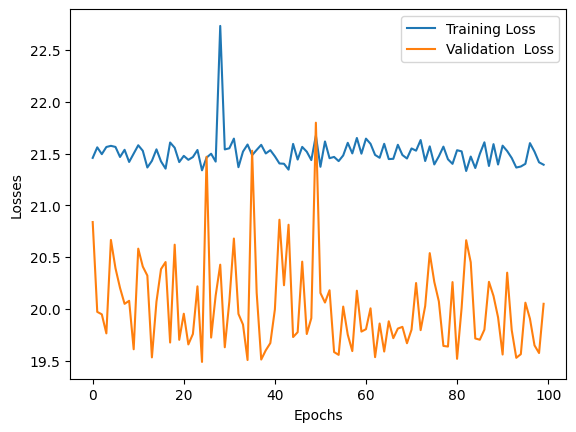

In [68]:
plt.plot(df_loss['Training Loss'],label='Training Loss')
plt.plot(df_loss['Validation Loss'],label='Validation  Loss')
plt.xlabel('Epochs')
plt.ylabel('Losses')
plt.legend()

In [69]:
model.load_state_dict(torch.load('Best_model.pt'))

<All keys matched successfully>

In [71]:
model.eval()
with torch.no_grad():
    train_pred=model(x_trian_tensor)
    test_pred=model(X_test_tensor)
    train_mse_loss=criterion(train_pred,y_train_tensor)
    test_mse_loss=criterion(test_pred,y_test_tensor)
    print('Train MSE= ',train_mse_loss.item())
    print('Test MSE=',test_mse_loss.item())


Train MSE=  21.139991760253906
Test MSE= 19.497249603271484


In [72]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,test_pred)

In [73]:
r2

0.9318621487104048

In [77]:
pred_df=pd.DataFrame(test_pred.numpy(),columns=['Predicted Values'])
actual_df=pd.DataFrame(y_test.values,columns=['Actual Values'])

In [80]:
last_df=pd.concat([pred_df,actual_df],axis=1)

In [81]:
last_df

,Predicted Values,Actual Values
0,435.436951,433.27
1,437.092346,438.16
2,460.983429,458.42
3,475.981842,480.82
4,435.268280,441.41
...,...,...
1909,451.387756,456.70
1910,431.766693,438.04
1911,467.758057,467.80
1912,431.221008,437.14
